##Load Data

keys: ['xdata', 'ydata']
X shape/dtype/min/max/nonzero: (60000, 784) float32 0.0 1.0 8994156
Y shape/dtype: (60000, 10) float64


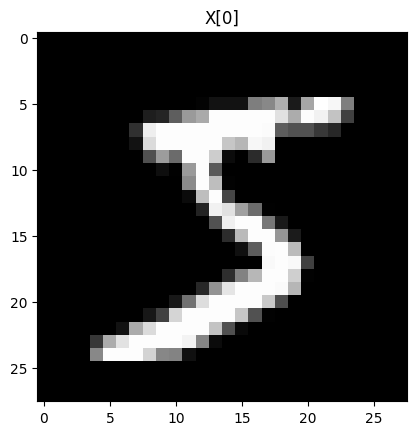

keys: ['xdata', 'ydata']
X shape/dtype/min/max/nonzero: (60000, 784) float32 0.0 1.0 8994156
Y shape/dtype: (60000, 10) float64


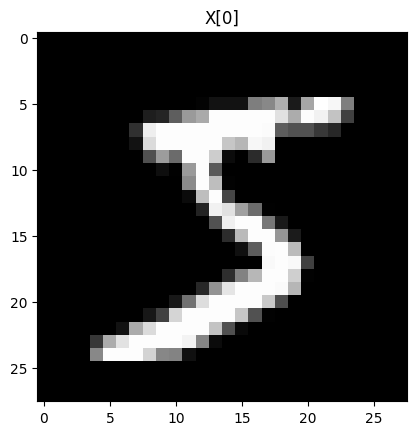

In [1]:
import h5py, numpy as np, matplotlib.pyplot as plt

TRAIN_H5 = '/content/drive/MyDrive/EE541 deep learning I/HW5/mnist_traindata.hdf5'
TEST_H5 = '/content/drive/MyDrive/EE541 deep learning I/HW5/mnist_testdata.hdf5'

def load_data(h5_path):
  with h5py.File(TRAIN_H5, 'r') as f:
      print("keys:", list(f.keys()))
      X = f['xdata'][:].astype(np.float32)
      Y = f['ydata'][:]
      #check the data shape
      print("X shape/dtype/min/max/nonzero:", X.shape, X.dtype, X.min(), X.max(), np.count_nonzero(X))
      print("Y shape/dtype:", Y.shape, Y.dtype)

      #show the first image ensure everything is right
      plt.imshow(X[0].reshape(28,28), cmap='gray')
      plt.title("X[0]")
      plt.show()

      return X, Y

X_train_raw, y_train_raw = load_data(TRAIN_H5)
X_test_raw, y_test_raw = load_data(TEST_H5)



In [2]:
y_train_raw

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

# Part (b): Softmax classification: gradient descent (GD)

In [3]:
# Normalize the X (no neeeds)
X_train = X_train_raw
X_test  = X_test_raw

# check the label
y_train = y_train_raw
y_test  = y_test_raw

print(y_train)

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


preprocessing_data

##Define helper function

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

def softmax(S):
    """
    Calculate Softmax activation function (N, K) -> (N, K)
    Uses stability trick (subtract max value)
    """
    S_stable = S - np.max(S, axis=1, keepdims=True)
    exp_S = np.exp(S_stable)
    P = exp_S / np.sum(exp_S, axis=1, keepdims=True)
    return P

def compute_loss_multi(Y_one_hot, P):
    """
    Calculate multi-class cross-entropy loss (Log-loss)
    Y_one_hot: (N, K) true labels
    P: (N, K) predicted probabilities
    """
    num_samples = Y_one_hot.shape[0]
    epsilon = 1e-9 # Avoid log(0)

    # We only care about the terms where Y_one_hot[i, k] == 1
    log_likelihood = -np.log(P[Y_one_hot.astype(bool)] + epsilon)
    loss = np.sum(log_likelihood) / num_samples

    return loss

def compute_accuracy_multi(Y_one_hot, P):
    """
    Calculate multi-class accuracy
    """
    y_pred_labels = np.argmax(P, axis=1)
    y_true_labels = np.argmax(Y_one_hot, axis=1)
    accuracy = np.mean(y_pred_labels == y_true_labels)
    return accuracy

VISUALIZATION AND SAVING

In [5]:
# --- 3. VISUALIZATION AND SAVING ---

def plot_curves(history,lr):
    """
    Plots the learning and accuracy curves.
    """
    iterations = range(1, len(history['train_loss']) + 1)

    # Plot Log-Loss (Learning Curve)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(iterations, history['train_loss'], label='Training Log-Loss')
    plt.plot(iterations, history['test_loss'], label='Test Log-Loss')
    plt.title('Learning Curve (Log-Loss vs. Iterations)')
    plt.xlabel('Iterations')
    plt.ylabel('Log-Loss')
    plt.grid(True)
    plt.legend()
    plt.savefig(f'/content/drive/MyDrive/EE541 deep learning I/HW6/output/b-GD_learning_curve_lr={lr}.png')

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(iterations, history['train_acc'], label='Training Accuracy')
    plt.plot(iterations, history['test_acc'], label='Test Accuracy')
    plt.title('Accuracy vs. Iterations')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/EE541 deep learning I/HW6/output/b-GD_accuracy_lr={lr}.png')
    plt.show()

def save_weights(weights, bias, outFile):
    """
    Saves the trained weights and bias to an HDF5 file.
    """
    with h5py.File(outFile, 'w') as hf:
        hf.create_dataset('w', data=np.asarray(weights))
        hf.create_dataset('b', data=np.asarray(bias))
    print(f"Model weights and bias saved to {outFile}")


## Implement Batch Gradient Descent

In [6]:
def train_softmax_regression(X_train, y_train, X_test, y_test, learning_rate, iterations, tol, patience):
    """
    Train Softmax Regression model
    """
    num_samples, num_features = X_train.shape
    num_classes = y_train.shape[1] # K = 10

    # 1. Initialize weights W and bias b
    # W matrix (D, K) -> (784, 10)
    # b vector (1, K) -> (1, 10)
    W = np.zeros((num_features, num_classes))
    b = np.zeros((1, num_classes))

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    best_loss = np.inf
    stale = 0

    print(f"Starting training with learning_rate={learning_rate}")

    for i in range(iterations):
        # --- (Batch) Forward Pass ---
        # S = X @ W + b
        S_train = np.dot(X_train, W) + b # (N, 10)
        P_train = softmax(S_train)      # (N, 10)

        # --- (Batch) Calculate Gradients ---
        # This is the matrix form of the result we derived in Q1
        E = P_train - y_train # (N, 10)

        # dL/dW = (1/N) * X.T @ E
        grad_W = (1 / num_samples) * np.dot(X_train.T, E) # (D, K)

        # dL/db = (1/N) * sum(E, axis=0)
        grad_b = (1 / num_samples) * np.sum(E, axis=0, keepdims=True) # (1, K)

        # --- (Batch) Parameter Update ---
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b

        # --- Evaluation and Logging ---
        if (i + 1) % 10 == 0 or i == 0: # Log every 10 iterations or the first time
            train_loss = compute_loss_multi(y_train, P_train)
            train_acc = compute_accuracy_multi(y_train, P_train)

            S_test = np.dot(X_test, W) + b
            P_test = softmax(S_test)
            test_loss = compute_loss_multi(y_test, P_test)
            test_acc = compute_accuracy_multi(y_test, P_test)

            history['train_loss'].append(train_loss)
            history['test_loss'].append(test_loss)
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)

            if (i + 1) % 100 == 0:
                print(f"Iteration {i+1}/{iterations} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

            # Early Stopping
            if best_loss - train_loss < tol:
                stale += 1
            else:
                stale = 0
                best_loss = train_loss

            if stale >= patience:
                print(f"Early stop at iter {i+1}")
                break

    return W, b, history

##Execute Training and Plotting

Starting training with learning_rate=0.5
Iteration 100/1000 | Train Loss: 0.3934 | Test Loss: 0.3926 | Test Acc: 0.8946
Iteration 200/1000 | Train Loss: 0.3471 | Test Loss: 0.3468 | Test Acc: 0.9043
Iteration 300/1000 | Train Loss: 0.3266 | Test Loss: 0.3265 | Test Acc: 0.9096
Iteration 400/1000 | Train Loss: 0.3143 | Test Loss: 0.3142 | Test Acc: 0.9127
Iteration 500/1000 | Train Loss: 0.3058 | Test Loss: 0.3057 | Test Acc: 0.9155
Iteration 600/1000 | Train Loss: 0.2995 | Test Loss: 0.2994 | Test Acc: 0.9170
Iteration 700/1000 | Train Loss: 0.2945 | Test Loss: 0.2944 | Test Acc: 0.9182
Iteration 800/1000 | Train Loss: 0.2905 | Test Loss: 0.2904 | Test Acc: 0.9193
Iteration 900/1000 | Train Loss: 0.2871 | Test Loss: 0.2870 | Test Acc: 0.9202
Iteration 1000/1000 | Train Loss: 0.2842 | Test Loss: 0.2842 | Test Acc: 0.9212

--- Final Model Evaluation ---
Final Training Loss: 0.2842
Final Training Accuracy: 0.9212
Final Test Loss: 0.2842
Final Test Accuracy: 0.9212


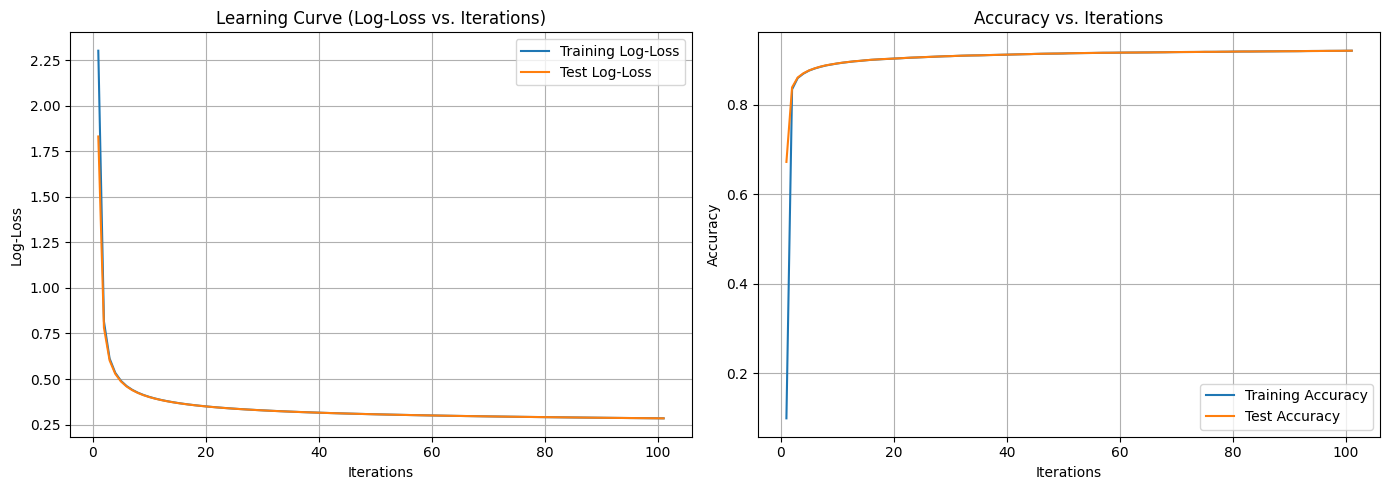

Model weights and bias saved to /content/drive/MyDrive/EE541 deep learning I/HW6/output/b_GD_weights_softmax_lr=0.5.h5


In [7]:
# --- Set hyperparameters ---
LEARNING_RATE = 0.5 # (Answer for Q2)
ITERATIONS    = 1000
PATIENCE      = 8
TOL           = 1e-6

# --- Execute Training ---
final_W, final_b, training_history = train_softmax_regression(
    X_train, y_train, X_test, y_test,
    LEARNING_RATE, ITERATIONS, TOL, PATIENCE
)

# --- (Answer for Q4) Final Evaluation ---
print("\n--- Final Model Evaluation ---")
S_train_final = np.dot(X_train, final_W) + final_b
P_train_final = softmax(S_train_final)
final_train_loss = compute_loss_multi(y_train, P_train_final)
final_train_acc = compute_accuracy_multi(y_train, P_train_final)
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Training Accuracy: {final_train_acc:.4f}")

S_test_final = np.dot(X_test, final_W) + final_b
P_test_final = softmax(S_test_final)
final_test_loss = compute_loss_multi(y_test, P_test_final)
final_test_acc = compute_accuracy_multi(y_test, P_test_final)
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}")

# --- (Answer for Q3) Plotting ---
plot_curves(training_history, LEARNING_RATE)

# --- Save Weights ---
save_weights(final_W, final_b, outFile=f'/content/drive/MyDrive/EE541 deep learning I/HW6/output/b_GD_weights_softmax_lr={LEARNING_RATE}.h5')

# Part (c): Softmax classification: stochastic gradient descent

Helper functions

In [8]:
import numpy as np
import time # To compare computation time

# --- Helper functions (softmax, compute_loss_multi, compute_accuracy_multi) ---
# --- Use the ones defined previously for Part (b) ---

def train_softmax_sgd(X_train, y_train, X_test, y_test,
                      learning_rate, epochs, batch_size,
                      log_interval_samples=5000): # Log metrics every 5000 samples
    """
    Train Softmax Regression model using Stochastic Gradient Descent (SGD).
    """
    num_samples, num_features = X_train.shape
    num_classes = y_train.shape[1] # K = 10

    # 1. Initialize weights W and bias b
    W = np.zeros((num_features, num_classes))
    b = np.zeros((1, num_classes))

    # History will store metrics at specified intervals
    # We'll store sample_count, train_loss, test_loss, train_acc, test_acc
    history = {'samples': [], 'train_loss': [], 'test_loss': [],
               'train_acc': [], 'test_acc': []}

    samples_processed_total = 0
    batches_processed_total = 0

    # --- Initial evaluation (Iteration 0 / Batch 0) ---
    print("Evaluating initial model...")
    S_test_initial = np.dot(X_test, W) + b
    P_test_initial = softmax(S_test_initial)
    initial_test_loss = compute_loss_multi(y_test, P_test_initial)
    initial_test_acc = compute_accuracy_multi(y_test, P_test_initial)

    # We estimate initial train loss/acc on the first batch for consistency
    X_batch_initial = X_train[:batch_size]
    y_batch_initial = y_train[:batch_size]
    S_train_initial = np.dot(X_batch_initial, W) + b
    P_train_initial = softmax(S_train_initial)
    initial_train_loss = compute_loss_multi(y_batch_initial, P_train_initial)
    initial_train_acc = compute_accuracy_multi(y_batch_initial, P_train_initial)

    history['samples'].append(0)
    history['train_loss'].append(initial_train_loss)
    history['test_loss'].append(initial_test_loss)
    history['train_acc'].append(initial_train_acc)
    history['test_acc'].append(initial_test_acc)
    print(f"Initial | Train Loss (est): {initial_train_loss:.4f} | Test Loss: {initial_test_loss:.4f} | Test Acc: {initial_test_acc:.4f}")

    next_log_point = log_interval_samples

    print(f"\nStarting SGD training with learning_rate={learning_rate}, epochs={epochs}, batch_size={batch_size}")
    start_time = time.time()

    for epoch in range(epochs):
        # --- Shuffle training data at the start of each epoch ---
        permutation = np.random.permutation(num_samples)
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train[permutation]

        # --- Iterate over mini-batches ---
        for i in range(0, num_samples, batch_size):
            # Get current mini-batch
            X_batch = X_train_shuffled[i : i + batch_size]
            y_batch = y_train_shuffled[i : i + batch_size]
            current_batch_size = X_batch.shape[0] # Handle last batch potentially being smaller

            # --- Forward Pass (on mini-batch) ---
            S_batch = np.dot(X_batch, W) + b # (B, 10)
            P_batch = softmax(S_batch)      # (B, 10)

            # --- Calculate Gradients (on mini-batch) ---
            # Note: We use 1/current_batch_size, not 1/N
            E = P_batch - y_batch # (B, 10)
            grad_W = (1 / current_batch_size) * np.dot(X_batch.T, E) # (D, K)
            grad_b = (1 / current_batch_size) * np.sum(E, axis=0, keepdims=True) # (1, K)

            # --- Parameter Update ---
            W -= learning_rate * grad_W
            b -= learning_rate * grad_b

            samples_processed_total += current_batch_size
            batches_processed_total += 1

            # --- Logging Periodically (based on samples processed) ---
            if samples_processed_total >= next_log_point:
                # Evaluate on the *current mini-batch* for sampled train metrics
                # Note: This is a noisy estimate of the full training loss/acc
                train_loss_sampled = compute_loss_multi(y_batch, P_batch)
                train_acc_sampled = compute_accuracy_multi(y_batch, P_batch)

                # Evaluate on the *entire test set*
                S_test = np.dot(X_test, W) + b
                P_test = softmax(S_test)
                test_loss = compute_loss_multi(y_test, P_test)
                test_acc = compute_accuracy_multi(y_test, P_test)

                history['samples'].append(samples_processed_total)
                history['train_loss'].append(train_loss_sampled)
                history['test_loss'].append(test_loss)
                history['train_acc'].append(train_acc_sampled)
                history['test_acc'].append(test_acc)

                print(f"Samples {samples_processed_total} | Train Loss (Sampled): {train_loss_sampled:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

                next_log_point += log_interval_samples # Set next logging point


    end_time = time.time()
    training_time = end_time - start_time
    print(f"\nTraining finished in {training_time:.2f} seconds.")

    return W, b, history, training_time

Visualization Data

In [9]:
def plot_curves_sgd(history, batch_size, lr, method_name="SGD"):
    """
    Plots the learning and accuracy curves for SGD vs. samples processed.
    """
    samples = history['samples']
    # If plotting vs batch number (for B=1, sample=batch number)
    # batch_numbers = [s / batch_size for s in samples] # Or just use samples directly if B=1

    plt.figure(figsize=(14, 5))

    # Plot Log-Loss
    plt.subplot(1, 2, 1)
    plt.plot(samples, history['train_loss'], label='Sampled Training Log-Loss')
    plt.plot(samples, history['test_loss'], label='Test Log-Loss')
    plt.title(f'{method_name} (B={batch_size}, lr={lr}) Learning Curve')
    plt.xlabel('Samples Processed')
    plt.ylabel('Log-Loss')
    plt.grid(True)
    plt.legend()
    plt.savefig(f'/content/drive/MyDrive/EE541 deep learning I/HW6/output/sgd_loss_b{batch_size}_lr{lr}.png')

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(samples, history['train_acc'], label='Sampled Training Accuracy')
    plt.plot(samples, history['test_acc'], label='Test Accuracy')
    plt.title(f'{method_name} (B={batch_size}, lr={lr}) Accuracy Curve')
    plt.xlabel('Samples Processed')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.savefig(f'/content/drive/MyDrive/EE541 deep learning I/HW6/output/sgd_acc_b{batch_size}_lr{lr}.png')

    plt.tight_layout()
    plt.show()

Q1: Implement SGD with Mini-batch Size 1

In [10]:
# --- Set hyperparameters for B=1 ---
LEARNING_RATE_SGD1 = 0.01 # SGD usually needs a smaller LR than BGD, start here and adjust
EPOCHS_SGD1 = 5          # Number of passes through the data, might need more/less
BATCH_SIZE_SGD1 = 1
LOG_INTERVAL_SAMPLES_SGD1 = 5000 # Log every 5000 samples

Evaluating initial model...
Initial | Train Loss (est): 2.3026 | Test Loss: 2.3026 | Test Acc: 0.0987

Starting SGD training with learning_rate=0.01, epochs=5, batch_size=1
Samples 5000 | Train Loss (Sampled): 0.0158 | Test Loss: 0.4071 | Test Acc: 0.8841
Samples 10000 | Train Loss (Sampled): 1.0217 | Test Loss: 0.3755 | Test Acc: 0.8935
Samples 15000 | Train Loss (Sampled): 0.0062 | Test Loss: 0.3532 | Test Acc: 0.8971
Samples 20000 | Train Loss (Sampled): 0.5384 | Test Loss: 0.3296 | Test Acc: 0.9062
Samples 25000 | Train Loss (Sampled): 0.0030 | Test Loss: 0.3415 | Test Acc: 0.9034
Samples 30000 | Train Loss (Sampled): 0.0911 | Test Loss: 0.3210 | Test Acc: 0.9092
Samples 35000 | Train Loss (Sampled): 0.2965 | Test Loss: 0.3159 | Test Acc: 0.9110
Samples 40000 | Train Loss (Sampled): 10.5907 | Test Loss: 0.3326 | Test Acc: 0.9036
Samples 45000 | Train Loss (Sampled): 0.0002 | Test Loss: 0.3122 | Test Acc: 0.9134
Samples 50000 | Train Loss (Sampled): 0.2657 | Test Loss: 0.2981 | Test

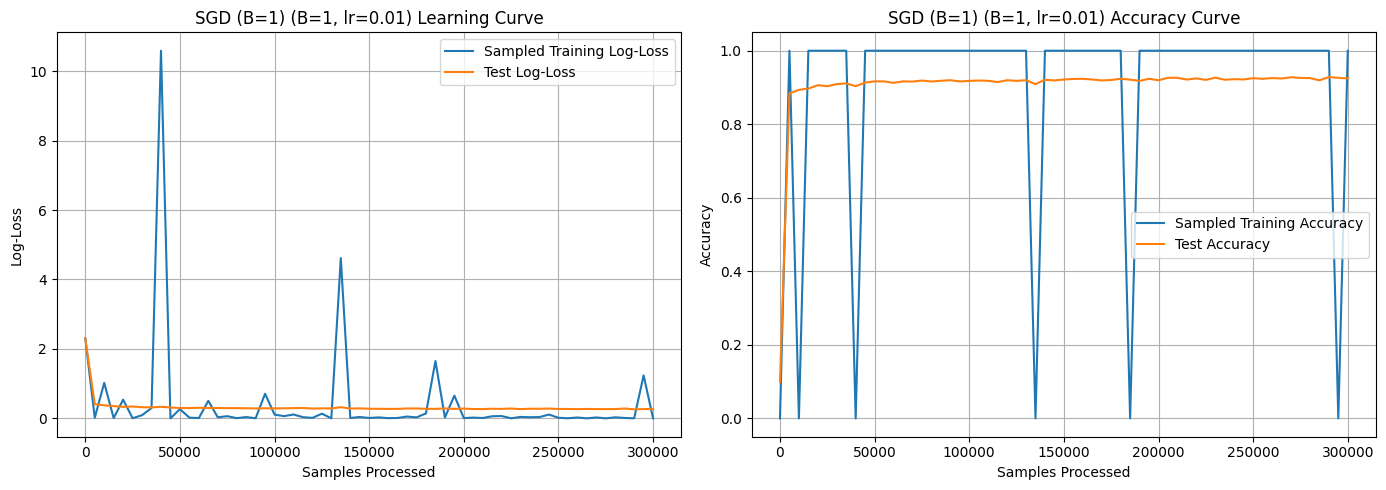

Model weights and bias saved to /content/drive/MyDrive/EE541 deep learning I/HW6/output/weights_sgd_b1_lr=0.01.h5


In [11]:
# --- Execute Training (B=1) ---
final_W_sgd1, final_b_sgd1, history_sgd1, time_sgd1 = train_softmax_sgd(
    X_train, y_train, X_test, y_test,
    LEARNING_RATE_SGD1, EPOCHS_SGD1, BATCH_SIZE_SGD1,
    LOG_INTERVAL_SAMPLES_SGD1
)

# --- Plot Results (B=1) ---
plot_curves_sgd(history_sgd1, BATCH_SIZE_SGD1, LEARNING_RATE_SGD1, "SGD (B=1)")
# --- Save Weights ---
save_weights(final_W_sgd1, final_b_sgd1, outFile=f'/content/drive/MyDrive/EE541 deep learning I/HW6/output/weights_sgd_b1_lr={LEARNING_RATE_SGD1}.h5')

Q3: Implement SGD with Mini-batch Size 100

Evaluating initial model...
Initial | Train Loss (est): 2.3026 | Test Loss: 2.3026 | Test Acc: 0.0987

Starting SGD training with learning_rate=0.1, epochs=10, batch_size=100
Samples 5000 | Train Loss (Sampled): 0.8479 | Test Loss: 0.7998 | Test Acc: 0.8392
Samples 10000 | Train Loss (Sampled): 0.5103 | Test Loss: 0.6144 | Test Acc: 0.8566
Samples 15000 | Train Loss (Sampled): 0.4611 | Test Loss: 0.5362 | Test Acc: 0.8676
Samples 20000 | Train Loss (Sampled): 0.6194 | Test Loss: 0.4914 | Test Acc: 0.8756
Samples 25000 | Train Loss (Sampled): 0.5887 | Test Loss: 0.4636 | Test Acc: 0.8793
Samples 30000 | Train Loss (Sampled): 0.3827 | Test Loss: 0.4431 | Test Acc: 0.8829
Samples 35000 | Train Loss (Sampled): 0.3661 | Test Loss: 0.4288 | Test Acc: 0.8842
Samples 40000 | Train Loss (Sampled): 0.3465 | Test Loss: 0.4135 | Test Acc: 0.8894
Samples 45000 | Train Loss (Sampled): 0.4656 | Test Loss: 0.4050 | Test Acc: 0.8896
Samples 50000 | Train Loss (Sampled): 0.2450 | Test Loss: 0.3961 | Tes

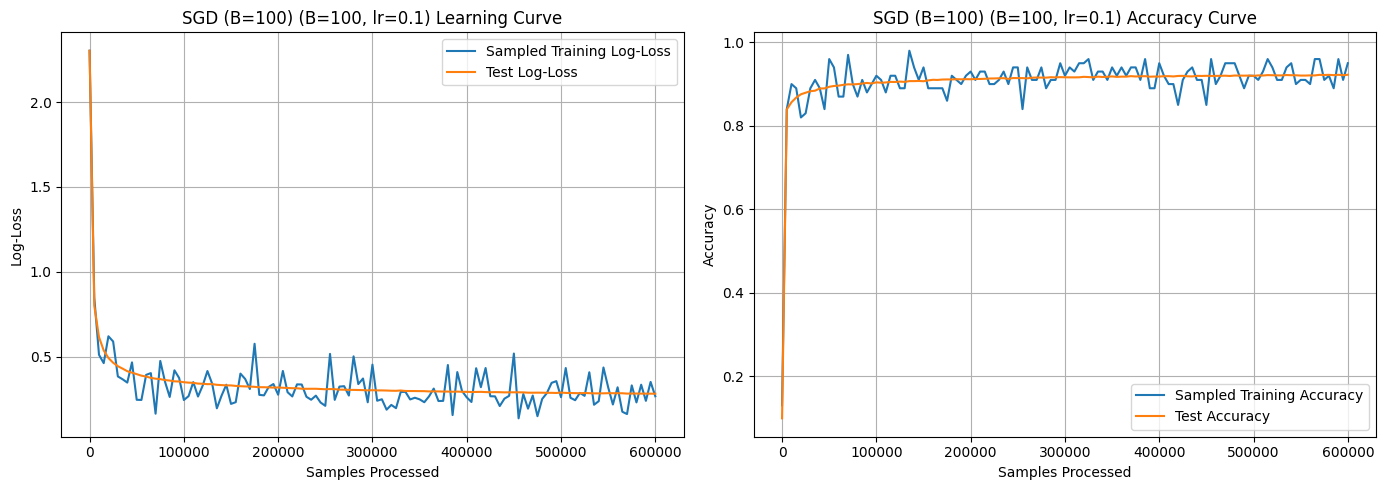

Model weights and bias saved to /content/drive/MyDrive/EE541 deep learning I/HW6/output/weights_sgd_b100_lr=0.1.h5


In [12]:
# --- Set hyperparameters for B=100 ---
LEARNING_RATE_SGD100 = 0.1 # Can often use a slightly larger LR than B=1, adjust as needed
EPOCHS_SGD100 = 10        # Might need more/less than B=1, maybe fewer epochs than B=1
BATCH_SIZE_SGD100 = 100
LOG_INTERVAL_SAMPLES_SGD100 = 5000 # Log every 50 batches (5000 samples)

# --- Execute Training (B=100) ---
final_W_sgd100, final_b_sgd100, history_sgd100, time_sgd100 = train_softmax_sgd(
    X_train, y_train, X_test, y_test,
    LEARNING_RATE_SGD100, EPOCHS_SGD100, BATCH_SIZE_SGD100,
    LOG_INTERVAL_SAMPLES_SGD100
)

# --- Plot Results (B=100) ---
plot_curves_sgd(history_sgd100, BATCH_SIZE_SGD100, LEARNING_RATE_SGD100, "SGD (B=100)")

# --- Save Weights ---
save_weights(final_W_sgd100, final_b_sgd100, outFile=f'/content/drive/MyDrive/EE541 deep learning I/HW6/output/weights_sgd_b100_lr={LEARNING_RATE_SGD100}.h5')